# Inferens 

Formål

I Notebook 01 så jeg på hvordan man bygger Markov-modeller og beregne teoretiske fordelinger. Nu vil jeg se på, når man har givet observerede genetiske data, hvilke parametre passer bedst. 

Dette er vigtigt, da det er det jeg vil gøre med bavian-data i de efterfølgende notebooks.

I denne notebook vil jeg komme ind på følgende:

1. **Method of Moments (MoM)** — hurtig, analytisk parameterestimering
2. **Bayesiansk inferens med SVGD** — fuld posterior-fordeling med usikkerhed
3. **To-populations model** — inferens med migration mellem populationer
4. **Posterior predictive checks** — validering af, om modellen passer til data
5. **Joint probability inferens** — brug af diskrete observationer (antal mutationer)


For at forstå bavianernes evolutionære historie skal jeg estimere parametre som effektiv populationsstørrelse ($N_e$) og migrationrater mellem populationer. Disse parametre fortæller os, hvornår populationer skiltes, og om der har været gene flow efterfølgende.

In [1]:
# Importer nødvendige pakker
# phasic skal altid importeres FØRST for at sætte JAX-backend korrekt
from phasic import (
    Graph, with_ipv, GaussPrior, MoMResult, ProbMatchResult,
    Adam, ExpStepSize, ExpRegularization, clear_caches, dense_to_sparse,
    StateIndexer, Property, set_log_level, HalfCauchyPrior, DataPrior,
)
import numpy as np
import jax.numpy as jnp
import pandas as pd
from typing import Optional
import matplotlib.pyplot as plt
import seaborn as sns
%config InlineBackend.figure_format = 'svg'
from tqdm.auto import tqdm
from vscodenb import set_vscode_theme

set_log_level('INFO')
np.random.seed(42)
set_vscode_theme()
sns.set_palette('tab10')

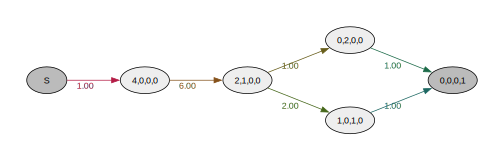

In [3]:
# Hjælpefunktion til at genbruge coalescent-modellen på tværs af sektioner, samme som blev defineret i notebook 01
nr_samples = 4

@with_ipv([nr_samples] + [0] * (nr_samples - 1))
def coalescent_1param(state):
    """Standard coalescent med én parameter (coalescence-rate = theta[0])."""
    transitions = []
    for i in range(state.size):
        for j in range(i, state.size):
            same = int(i == j)
            if same and state[i] < 2: continue
            if not same and (state[i] < 1 or state[j] < 1): continue
            new = state.copy()
            new[i] -= 1
            new[j] -= 1
            new[i + j + 1] += 1
            transitions.append([new, [state[i] * (state[j] - same) / (1 + same)]])
    return transitions

graph = Graph(coalescent_1param)
graph.plot()

## 1. Method of Moments (MoM)

Method of Moments er en statistisk metode: jeg *matcher empiriske momenter* (gennemsnit, varians, ...) fra data med de *teoretiske momenter* fra modellen. Den parameter-kombination, der giver den bedste match, er vores estimat.

Fordele:

- Hurtig og analytisk
- Giver et godt startpunkt for mere avanceret inferens

Begrænsninger:

- Giver kun punktestimater, ikke en fuld fordeling over parametre
- Kan have svært ved komplekse, ikke-identifierbare modeller

Jeg simulerer her data fra en model med *sand theta = 7* og forsøger at genfinde den.

In [4]:
# Sæt sand parameter og simuler observationer
# I en reel analyse ville 'observed_data' komme fra bavian-genomet
graph = Graph(coalescent_1param)

true_theta = [7]
graph.update_weights(true_theta)
observed_data = graph.sample(1000)

print(f"Simuleret: {len(observed_data)} observationer")
print(f"Empirisk gennemsnit: {np.mean(observed_data):.4f}")
print(f"Empirisk varians:    {np.var(observed_data):.4f}")

Simuleret: 1000 observationer
Empirisk gennemsnit: 0.2207
Empirisk varians:    0.0244


In [5]:
# Kør Method of Moments estimering
mom = graph.method_of_moments(observed_data)

print("=== Method of Moments Resultat ===")
print(f"Sand theta:     {true_theta}")
print(f"MoM estimat:    {mom.theta}")
print(f"Std. fejl:      {mom.std}")
print(f"Konvergeret:    {mom.success}")
print(f"Residual:       {mom.residual:.2e}")
print()
print("Sammenligning af momenter:")
print(f"  Empiriske:   {mom.sample_moments}")
print(f"  Model:       {mom.model_moments}")

W0408 13:34:04.929142  280535 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
[INFO] phasic.method_of_moments: theta_dim=1, n_free=1, nr_moments=3, n_features=1, n_equations=3
[INFO] phasic.method_of_moments: sample moments =
[[0.22067459 0.0731022  0.03439778]]
[INFO] phasic.method_of_moments: initial guess (full theta) = [6.95192796]
[INFO] phasic.method_of_moments: weighted GMM step 2 (cholesky): converged
[INFO] phasic.method_of_moments: converged — `ftol` termination condition is satisfied.
[INFO] phasic.method_of_moments: theta = [6.80129267]
[INFO] phasic.method_of_moments: residual = 1.520760e+00
[INFO] phasic.method_of_moments: model moments =
[0.22054631 0.07326126 0.03363939]


=== Method of Moments Resultat ===
Sand theta:     [7]
MoM estimat:    [6.80129267]
Std. fejl:      [0.14881762]
Konvergeret:    True
Residual:       1.52e+00

Sammenligning af momenter:
  Empiriske:   [[0.22067459 0.0731022  0.03439778]]
  Model:       [0.22054631 0.07326126 0.03363939]


## 2. Bayesiansk inferens med SVGD

MoM giver os et tal. Men i genetik er usikkerhed afgørende og jeg ønsker at vide: *hvad er sandsynlighedsfordelingen over mulige parameterværdier givet data?* Dette er den *posterior-fordeling* i Bayesiansk statistik.

Phasic bruger **SVGD** (*Stein Variational Gradient Descent*): en algoritme der iterativt bevæger en sværm af "partikler" (kandidatparametre) mod den sande posterior ved hjælp af gradientinformation. Det er en alternativ til MCMC, der er bedre egnet til hurtig, differentiabel inferens.

**Prior-fordelingen** udtrykker vores viden *før* data. Her bruger jeg et bredt prior, der afspejler stor usikkerhed om theta.

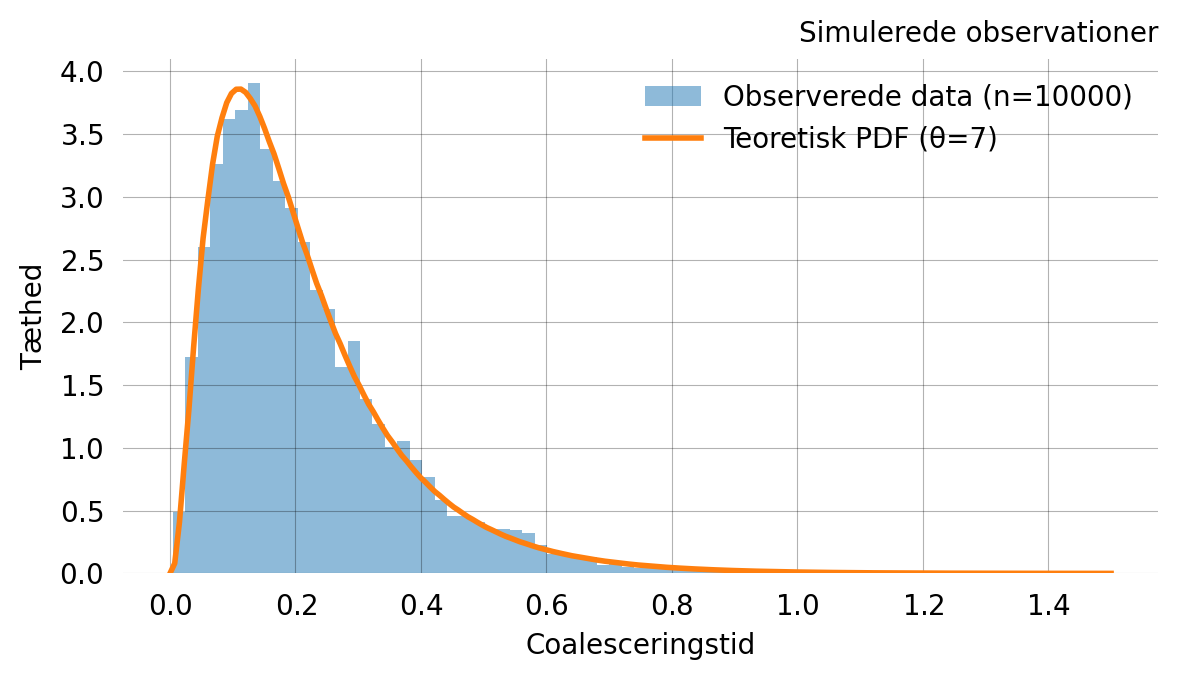

In [6]:
# Simuler et større datasæt for mere præcis estimering
nr_observations = 10000
graph.update_weights(true_theta)
observed_data = graph.sample(nr_observations)

# Visualiser data mod den teoretiske PDF
x = np.linspace(0, 1.5, 200)
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.hist(observed_data, density=True, bins=60, alpha=0.5, 
        label=f'Observerede data (n={nr_observations})', color='C0')
ax.plot(x, graph.pdf(x), color='C1', lw=2, label=f'Teoretisk PDF (θ={true_theta[0]})')
ax.set_xlabel("Coalesceringstid")
ax.set_ylabel("Tæthed")
ax.set_title("Simulerede observationer")
ax.legend()
plt.tight_layout()
plt.show()

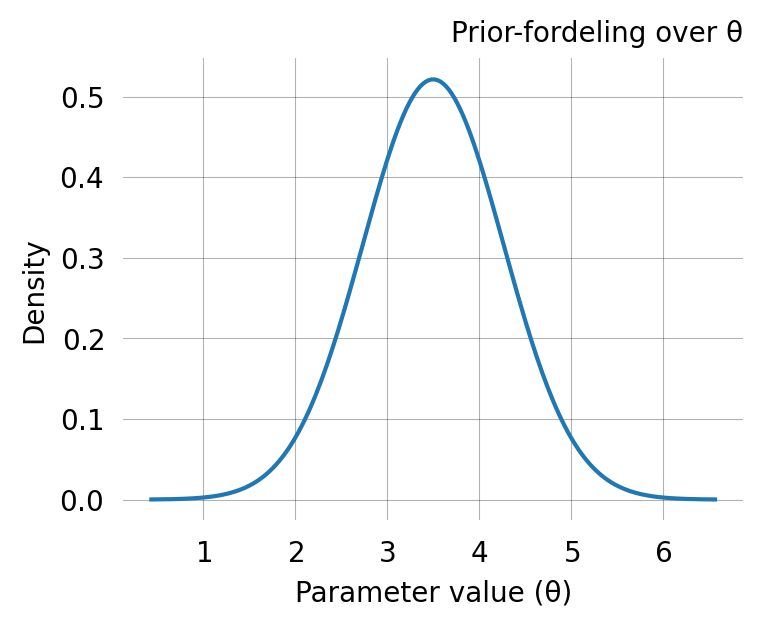

In [7]:
# Definer et bredt prior (stor usikkerhed om parameterværdien)
prior = GaussPrior(ci=[2, 5])
prior.plot()
plt.title("Prior-fordeling over θ")
plt.show()

In [8]:
# Kør SVGD-inferens
# step_schedule: learning rate falder eksponentielt, starter bredt og præciserer
step_schedule = ExpStepSize(first_step=0.05, last_step=0.01, tau=30.0)

svgd = graph.svgd(
    observed_data,
    prior=prior,
    learning_rate=step_schedule
)

print("=== SVGD Inferens Resultat ===")
print(f"Sand theta: {true_theta}")
svgd.summary()

ValueError: Sharding passed to jit does not match the sharding on the respective arg. Got jit sharding: NamedSharding(mesh=Mesh('batch': 16, axis_types=(Auto,)), spec=P('batch',), memory_kind=device),
arg sharding: NamedSharding(mesh=Mesh('batch': 16, axis_types=(Auto,)), spec=P(), memory_kind=device) for arg type: float64[16,2,1]

In [ ]:
# Visualiser posterior med konfidensinterval og sand parameter
# Den blå region er 95% konfidensinterval for theta
svgd.plot_ci(true_theta=true_theta)
plt.title("Posterior for θ (95% CI)")
plt.show()

In [ ]:
# Konvergensplot: er partiklerne stoppet med at bevæge sig?
# Fladende kurve = god konvergens
svgd.plot_convergence()
plt.show()

### Posterior Predictive Check

En god model kan *gengive de observerede data*. Jeg tjekker dette ved at sætte parametrene til posterior-gennemsnittet og sammenligne den modelbaserede PDF/CDF med de empiriske data. Tæt match = modellen forklarer data godt.

In [9]:
from scipy.stats import ecdf

res = ecdf(observed_data)
x_ecdf, ecdf_vals = res.cdf.quantiles, res.cdf.probabilities

# Opdater grafen med posterior-gennemsnittet
graph.update_weights(svgd.get_results()['theta_mean'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3.5))

# PDF vs. histogram
sns.histplot(observed_data, kde=False, stat='density', label='Data', ax=ax1, alpha=0.5)
ax1.plot(x_ecdf, graph.pdf(x_ecdf), lw=2, c='C1', label='Model PDF')
ax1.set_xlabel('Coalesceringstid')
ax1.set_title('PDF — Posterior predictive check')
ax1.legend()

# CDF vs. empirisk CDF
ax2.plot(x_ecdf, ecdf_vals, lw=2, c='C0', label='Empirisk CDF')
ax2.plot(x_ecdf, graph.cdf(x_ecdf), lw=2, c='C1', label='Model CDF')
ax2.set_xlabel('Coalesceringstid')
ax2.set_title('CDF — Posterior predictive check')
ax2.legend()

# Residualplot (højre akse)
ax3 = ax2.twinx()
ax3.plot(x_ecdf, graph.cdf(x_ecdf) - ecdf_vals, lw=0.8, c='C2', alpha=0.7, label='CDF - ECDF')
ax3.axhline(0, ls='--', color='C2', lw=0.5)
ax3.set_ylabel('Residual (CDF − ECDF)', color='C2')
ax3.tick_params(axis='y', colors='C2')
ax3.grid(False)

plt.tight_layout()
plt.show()

NameError: name 'svgd' is not defined

## 3. To-populations model med migration

### Fra en til to populationer

Den simple coalescent antager en homogen population. For bavianerne er det ikke realistisk, der er flere geografisk adskilte grupper med potentiel migration imellem.

**To-ø modellen** (*island model*) tilføjer to processer:

1. **Coalescence** inden for hver population (rate ∝ 1/$N_e$)
2. **Migration** mellem populationer (rate ∝ migrationrate $m$)

State-vektoren udvides nu til at indeholde information om:

- Hvilke populationers efterkommere en lineage bærer (`pop1`, `pop2`)
- I hvilken population lineagen befinder sig (`in_pop`)

Denne model er en forenklet forløber for de mere realistiske bavian-modeller i de efterfølgende notebooks.

In [10]:
nr_samples = 2

indexer = StateIndexer(
    descendants=[
        Property('pop1', min_value=0, max_value=nr_samples),
        Property('pop2', min_value=0, max_value=nr_samples),
        Property('in_pop', min_value=1, max_value=2),
    ]
)

# Startstate: alle lineages er singletons fra population 1
initial = [0] * indexer.state_length
initial[indexer.descendants.props_to_index(pop1=1, pop2=0, in_pop=1)] = nr_samples

@with_ipv(initial)
def two_island(state):
    """
    To-ø model med to parametre:
      theta[0] = coalescence-rate (∝ 1/N_e)
      theta[1] = migrationrate (m)
    """
    transitions = []
    if state[indexer.descendants.indices()].sum() <= 1:
        return transitions

    for i in range(indexer.descendants.state_length):
        if state[i] == 0: continue
        props_i = indexer.descendants.index_to_props(i)

        for j in range(i, indexer.descendants.state_length):
            if state[j] == 0: continue
            props_j = indexer.descendants.index_to_props(j)

            # Coalescence kræver at begge lineages er i samme population
            if props_j.in_pop != props_i.in_pop:
                continue

            same = int(i == j)
            if same and state[i] < 2: continue
            if not same and (state[i] < 1 or state[j] < 1): continue

            child = state.copy()
            child[i] -= 1
            child[j] -= 1
            des_pop1 = props_i.pop1 + props_j.pop1
            des_pop2 = props_i.pop2 + props_j.pop2
            if des_pop1 <= nr_samples and des_pop2 <= nr_samples:
                k = indexer.descendants.props_to_index(
                    pop1=des_pop1, pop2=des_pop2, in_pop=props_i.in_pop)
                child[k] += 1
                transitions.append([child, [state[i] * (state[j] - same) / (1 + same), 0]])

        # Migration: lineagen skifter population
        if state[i] > 0:
            child = state.copy()
            other_pop = 2 if props_i.in_pop == 1 else 1
            child[i] -= 1
            k = indexer.descendants.props_to_index(
                pop1=props_i.pop1, pop2=props_i.pop2, in_pop=other_pop)
            child[k] += 1
            transitions.append([child, [0, state[i]]])

    return transitions

graph_2pop = Graph(two_island)

# Sæt sande parametre og simuler data
true_theta = [0.7, 0.3]   # coalescence-rate, migrationrate
graph_2pop.update_weights(true_theta)
observations_2pop = graph_2pop.sample(1000)

print(f"To-populations model: {graph_2pop.param_length()} parametre")
print(f"  theta[0] = coalescence-rate = {true_theta[0]} (∝ 1/N_e)")
print(f"  theta[1] = migrationrate    = {true_theta[1]}")

To-populations model: 2 parametre
  theta[0] = coalescence-rate = 0.7 (∝ 1/N_e)
  theta[1] = migrationrate    = 0.3


In [11]:
# MoM estimering som udgangspunkt
mom_2pop = graph_2pop.method_of_moments(observations_2pop)

print("=== MoM estimat (to-populations model) ===")
print(f"Sand theta:    {true_theta}")
print(f"MoM estimat:   {mom_2pop.theta}")
print(f"Std. fejl:     {mom_2pop.std}")
print(f"Konvergeret:   {mom_2pop.success}")

[INFO] phasic.method_of_moments: theta_dim=2, n_free=2, nr_moments=2, n_features=1, n_equations=2
[INFO] phasic.method_of_moments: sample moments =
[[ 2.81152812 20.5715157 ]]
[INFO] phasic.method_of_moments: initial guess (full theta) = [0.65348084 8.02366105]
[INFO] phasic.method_of_moments: weighted GMM step 2 (cholesky): converged
[INFO] phasic.method_of_moments: converged — `gtol` termination condition is satisfied.
[INFO] phasic.method_of_moments: theta = [0.71135693 0.29519618]
[INFO] phasic.method_of_moments: residual = 2.198429e-28
[INFO] phasic.method_of_moments: model moments =
[ 2.81152812 20.5715157 ]


=== MoM estimat (to-populations model) ===
Sand theta:    [0.7, 0.3]
MoM estimat:   [0.71135693 0.29519618]
Std. fejl:     [0.02849025 0.04496041]
Konvergeret:   True


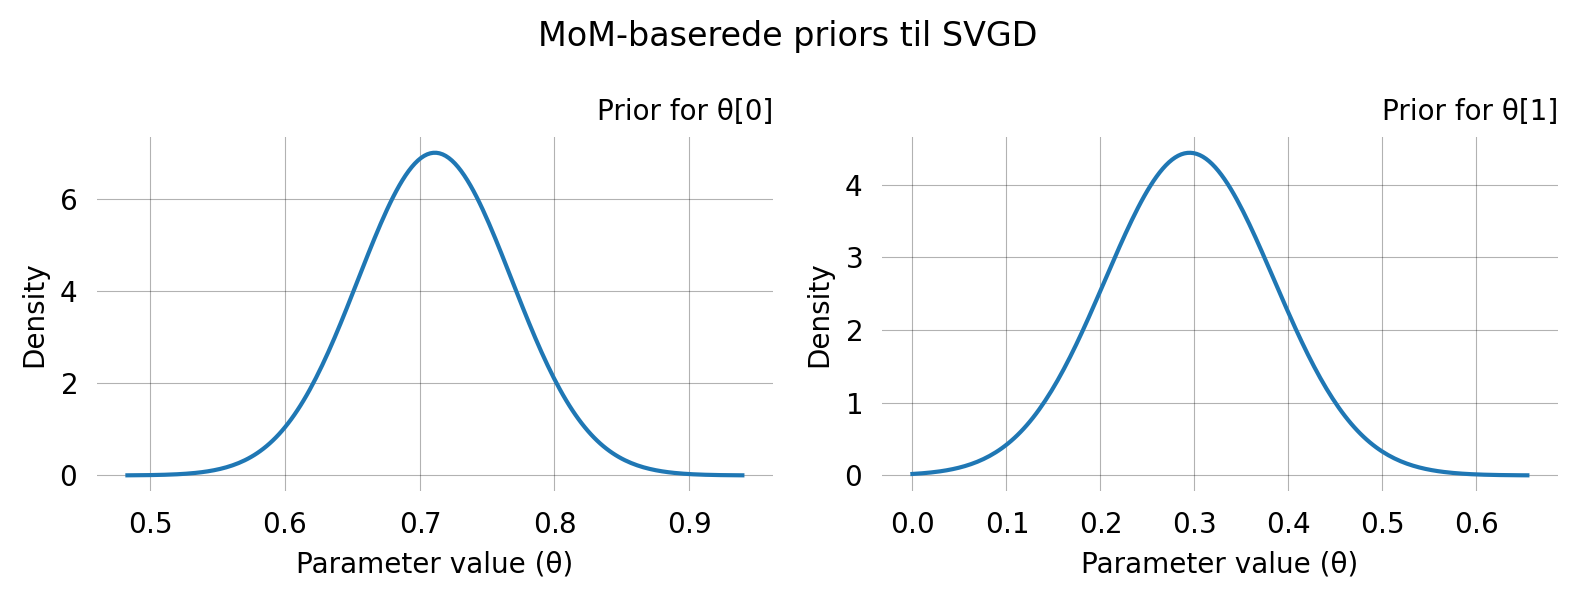

In [12]:
# SVGD med prior fra MoM-resultatet
# MoM giver os automatisk et fornuftigt informeret prior
fig, axes = plt.subplots(1, len(mom_2pop.prior), figsize=(8, 3))
for i, prior in enumerate(mom_2pop.prior):
    prior.plot(return_ax=True, ax=axes[i])
    axes[i].set_title(f"Prior for θ[{i}]")
plt.suptitle("MoM-baserede priors til SVGD")
plt.tight_layout()
plt.show()

In [13]:
# Kør SVGD inferens på to-populations modellen
svgd_2pop = graph_2pop.svgd(
    observations_2pop,
    prior=mom_2pop.prior,
    learning_rate=ExpStepSize(first_step=0.05, last_step=0.005, tau=20.0),
)

print("=== SVGD Resultat (to-populations model) ===")
svgd_2pop.summary()

ValueError: Sharding passed to jit does not match the sharding on the respective arg. Got jit sharding: NamedSharding(mesh=Mesh('batch': 16, axis_types=(Auto,)), spec=P('batch',), memory_kind=device),
arg sharding: NamedSharding(mesh=Mesh('batch': 16, axis_types=(Auto,)), spec=P(), memory_kind=device) for arg type: float64[16,3,2]

In [ ]:
# Pairwise posterior: viser fordelingen over begge parametre og korrelation imellem dem
# Korrelation mellem theta[0] og theta[1] er vigtig — det fortæller os om parametrene
# er identifierbare fra data
svgd_2pop.plot_pairwise(true_theta=true_theta)
plt.suptitle("Posterior-fordeling: coalescence vs. migration", y=1.02)
plt.show()

## 4. Inferens med multiple observationstyper (rewards)

Mere information = bedre estimater

Frem for at bruge en statistik (fx gennemsnitlig coalesceringstid) kan vi bruge *multiple features* samtidigt fx singleton-grenvarighed, doubleton-grenvarighed, tripleton-grenvarighed. Disse er netop komponenterne i SFS'en fra Notebook 1.

Fordelen: jeg udnytter mere af informationen i data, og estimater bliver mere præcise. Dette er relevant for bavian-data, hvor jeg kan udtrække hele SFS som observationsvektor.

In [14]:
# Genbyg en-parameters model
graph_1p = Graph(coalescent_1param)
true_theta_1p = [7]
graph_1p.update_weights(true_theta_1p)

# Reward-matrix: én feature per lineage-type (singleton, doubleton, tripleton)
states = graph_1p.states().T
rewards = states[:-1]   # udelad den absorberende tilstand

print(f"Reward-matrixens form: {rewards.shape}")
print(f"  → {rewards.shape[0]} features (lineage-typer) × {rewards.shape[1]} tilstande")

# Simuler data for hver feature separat
n_obs = 10000
n_features = rewards.shape[0]
observed_data_2d = np.zeros((n_obs * n_features, n_features), dtype=float)
observed_data_2d[:] = np.nan
for i in range(n_features):
    observed_data_2d[(i * n_obs):((i + 1) * n_obs), i] = graph_1p.sample(n_obs, rewards=rewards[i])

sparse_data = dense_to_sparse(observed_data_2d)
print(f"\nSamlet datasæt: {n_obs} observationer × {n_features} features")

Reward-matrixens form: (3, 6)
  → 3 features (lineage-typer) × 6 tilstande

Samlet datasæt: 10000 observationer × 3 features


In [15]:
# MoM med multiple features
# Matcher nu momenter for alle 3 lineage-typer simultant
mom_multi = graph_1p.method_of_moments(sparse_data, rewards=rewards)

print("=== MoM med multiple features ===")
print(f"Sand theta:   {true_theta_1p}")
print(f"MoM estimat:  {mom_multi.theta}")
print(f"Konvergeret:  {mom_multi.success}")
print()
print("Sample vs. model momenter per feature:")
labels = ["Singleton", "Doubleton", "Tripleton"]
for i, label in enumerate(labels):
    print(f"  {label}: empirisk={mom_multi.sample_moments[i]:.4f},  model={mom_multi.model_moments[i]:.4f}")

[INFO] phasic.method_of_moments: theta_dim=1, n_free=1, nr_moments=2, n_features=3, n_equations=6
[INFO] phasic.method_of_moments: sample moments =
[[0.28670089 0.11875542]
 [0.14523671 0.06959062]
 [0.09531163 0.02722738]]
[INFO] phasic.method_of_moments: initial guess (full theta) = [6.95192796]
[INFO] phasic.method_of_moments: weighted GMM step 2 (cholesky): converged
[INFO] phasic.method_of_moments: converged — Both `ftol` and `xtol` termination conditions are satisfied.
[INFO] phasic.method_of_moments: theta = [6.96658798]
[INFO] phasic.method_of_moments: residual = 1.137992e+00
[INFO] phasic.method_of_moments: model moments =
[[0.28708458 0.11904758]
 [0.14354229 0.0686813 ]
 [0.09569486 0.02747252]]


=== MoM med multiple features ===
Sand theta:   [7]
MoM estimat:  [6.96658798]
Konvergeret:  True

Sample vs. model momenter per feature:


TypeError: unsupported format string passed to numpy.ndarray.__format__

## 5. Joint probability inferens med mutationsdata

I rigtige genomdata observerer jeg *ikke* coalesceringstider direkte. Man observerer *antal mutationer* fx antal SNPs der deles af præcis *k* individer. Dette er diskrete tælledata.

*Joint probability-grafen* kobler coalescent-teorien til mutationsmodellen og giver os sandsynligheden for at observere et bestemt mønster af mutationstal. Denne tilgang er direkte anvendelig på bavian-data.

Modellen har nu to parametre:

- $\theta$ = coalescence-rate (proportional med $1/N_e$)
- $\mu$ = mutationsrate (fikseret, estimeres separat)

In [16]:
from functools import partial
from itertools import combinations_with_replacement

all_pairs = partial(combinations_with_replacement, r=2)

nr_samples = 4
indexer_jp = StateIndexer(
    lineage=[Property('descendants', min_value=1, max_value=nr_samples)]
)

@with_ipv([nr_samples] + [0] * (nr_samples - 1))
def coalescent_jp(state):
    transitions = []
    for i, j in all_pairs(indexer_jp.lineage):
        p1 = indexer_jp.lineage.index_to_props(i)
        p2 = indexer_jp.lineage.index_to_props(j)
        same = int(i == j)
        if same and state[i] < 2: continue
        if not same and (state[i] < 1 or state[j] < 1): continue
        new = state.copy()
        new[i] -= 1
        new[j] -= 1
        descendants = p1.descendants + p2.descendants
        k = indexer_jp.lineage.props_to_index(descendants=descendants)
        new[k] += 1
        transitions.append([new, [state[i] * (state[j] - same) / (1 + same)]])
    return transitions

base_graph = Graph(coalescent_jp)

# Byg joint probability-grafen
# tot_reward_limit: max antal mutationer vi modellerer
mutation_rate = 1.0
joint_graph = base_graph.joint_prob_graph(
    indexer_jp, tot_reward_limit=2, mutation_rate=mutation_rate
)

print(f"Joint probability-graf: {joint_graph.vertices_length()} tilstande")
print(f"Antal parametre: {joint_graph.param_length()}")
print(f"  theta[0] = coalescence-rate")
print(f"  theta[1] = mutation_rate (fikseres til {mutation_rate})")

Joint probability-graf: 39 tilstande
Antal parametre: 2
  theta[0] = coalescence-rate
  theta[1] = mutation_rate (fikseres til 1.0)


In [17]:
# Sæt sande parametre og vis joint probability-tabellen
true_theta_jp = [7.0, mutation_rate]
joint_graph.update_weights(true_theta_jp)

table = joint_graph.joint_prob_table()
print("Joint probability-tabel (uddrag):")
print(table.head(10).to_string())
print(f"\nTotal sandsynlighed: {table['prob'].sum().item():.4f}")
print("(Resten er sandsynlighed for >2 mutationer, som vi ikke modellerer)")

Joint probability-tabel (uddrag):
                descendants_1  descendants_2  descendants_3  descendants_4      prob
t_vertex_index                                                                      
9                           0              0              0              0  0.621377
18                          0              1              0              0  0.071919
20                          1              0              0              0  0.151842
23                          0              0              1              0  0.046028
30                          0              2              0              0  0.013225
31                          2              0              0              0  0.026469
32                          1              0              1              0  0.018067
33                          0              0              2              0  0.005114
34                          1              1              0              0  0.016322
35                          0  

In [18]:
# Simuler diskrete observationer fra joint probability-tabellen
# Dette svarer til at "observere" antal mutationer per genomposition
def sample_joint_observations(joint_prob_graph, theta, nr_observations=1000):
    """Sample diskrete observationer fra joint probability-modellen."""
    joint_prob_graph.update_weights(theta)
    joint_prob_table = joint_prob_graph.joint_prob_table()
    p = joint_prob_table['prob'] / joint_prob_table['prob'].sum()
    p = p.to_numpy()
    sample = np.random.choice(joint_prob_table.index.values, nr_observations, p=p)
    feature_cols = joint_prob_table.columns[:-1]
    observations = [tuple(int(x) for x in row)
                    for row in joint_prob_table.loc[sample, feature_cols].values]
    return observations

observations_jp = sample_joint_observations(joint_graph, true_theta_jp, nr_observations=1000)
print(f"Simulerede diskrete observationer (første 5):")
print(observations_jp[:5])
print(f"\nFormat: (antal singletons, antal doubletons, antal tripletons, antal quadrupletons)")

Simulerede diskrete observationer (første 5):
[(0, 0, 0, 0), (1, 0, 0, 0), (0, 0, 0, 0), (0, 0, 0, 0), (0, 0, 0, 0)]

Format: (antal singletons, antal doubletons, antal tripletons, antal quadrupletons)


In [ ]:
# SVGD inferens på diskrete mutationsdata
# theta[1] (mutation_rate) fikseres — den estimeres typisk fra anden kilde
svgd_jp = joint_graph.svgd(
    observations_jp,
    fixed=[(1, mutation_rate)],   # Fiksér mutation_rate
    n_iterations=200,
    learning_rate=ExpStepSize(first_step=0.05, last_step=0.005, tau=30.0),
)

print("=== SVGD Inferens på mutationsdata ===")
print(f"Sand theta[0] (coalescence): {true_theta_jp[0]}")
svgd_jp.summary(ci_method='hpd', ci_level=0.95)

In [ ]:
svgd_jp.plot_ci(ci_method='hpd')
plt.title("Posterior for coalescence-rate (estimeret fra mutationstal)")
plt.show()

svgd_jp.plot_convergence()
plt.title("SVGD konvergens")
plt.show()

## Opsummering

I denne notebook har vi gennemgået de centrale inferens-metoder, vi vil anvende på bavian-data:

| Metode | Hvad den giver | Hvornår vi bruger den |
|---|---|---|
| **Method of Moments** | Hurtigt punktestimat | Startsæt for SVGD, hurtig sanity check |
| **SVGD (enkelt parameter)** | Fuld posterior + usikkerhed | Enkel en-populations model |
| **SVGD (to parametre)** | Joint posterior, korrelationer | To-populations modeller med migration |
| **Multi-feature MoM** | Bedre estimater via SFS | Udnyt hele SFS, ikke kun gennemsnittet |
| **Joint probability SVGD** | Inferens fra tælledata | Direkte på genomdata med SNP-tæller |

### Næste skridt

Nu er vi klar til at arbejde med rigtige bavian-data. I de næste notebooks:

- **Notebook 3** — Databehandling og beregning af SFS fra bavian-genomdata
- **Notebook 4** — Tilpasning af simple demografiske modeller til bavian-data
- **Notebook 5+** — Udvidede modeller med admixture og ghost-populationer

De metoder vi har lært her er præcis de samme — vi erstatter blot de simulerede data med rigtige genomdata.